Extração

In [ ]:
import pandas as pd
import json

In [ ]:
# Carregar o arquivo JSON
with open("TelecomX_Data.json", "r") as file:
    json_data = json.load(file)

Transformação

In [ ]:
# Normalizar o JSON para um formato tabular
df = pd.json_normalize(json_data)

In [ ]:
# Verificar a estrutura do DataFrame
print("Primeiras linhas do DataFrame normalizado:\n", df.head())
print("\nColunas do DataFrame:", df.columns.tolist())
print("\nTipos de dados:\n", df.dtypes)

Primeiras linhas do DataFrame normalizado:
    customerID Churn customer.gender  customer.SeniorCitizen customer.Partner  \
0  0002-ORFBO    No          Female                       0              Yes   
1  0003-MKNFE    No            Male                       0               No   
2  0004-TLHLJ   Yes            Male                       0               No   
3  0011-IGKFF   Yes            Male                       1              Yes   
4  0013-EXCHZ   Yes          Female                       1              Yes   

  customer.Dependents  customer.tenure phone.PhoneService phone.MultipleLines  \
0                 Yes                9                Yes                  No   
1                  No                9                Yes                 Yes   
2                  No                4                Yes                  No   
3                  No               13                Yes                  No   
4                  No                3                Yes             

In [ ]:
# Tratar listas ou dicionários remanescentes
for coluna in df.columns:
    if df[coluna].apply(lambda x: isinstance(x, (list, dict))).any():
        print(f"Coluna '{coluna}' contém listas ou dicionários. Convertendo para string...")
        df[coluna] = df[coluna].astype(str)

In [ ]:
# Padronizar colunas categóricas (ex.: gender, Churn, InternetService)
colunas_categoricas = ['gender', 'Churn', 'InternetService', 'customer.phone', 'account']
for coluna in colunas_categoricas:
    if coluna in df.columns:
        try:
            # Converter para minúsculas e remover espaços extras
            df[coluna] = df[coluna].str.lower().str.strip()
            print(f"Valores únicos em '{coluna}' após padronização: {df[coluna].unique()}")
        except AttributeError:
            print(f"Coluna '{coluna}' contém dados não compatíveis. Já convertida para string.")
    else:
        print(f"Coluna '{coluna}' não encontrada no DataFrame.")

Coluna 'gender' não encontrada no DataFrame.
Valores únicos em 'Churn' após padronização: ['no' 'yes' '']
Coluna 'InternetService' não encontrada no DataFrame.
Coluna 'customer.phone' não encontrada no DataFrame.
Coluna 'account' não encontrada no DataFrame.


In [ ]:
# Garantir que colunas numéricas sejam do tipo correto (ex.: MonthlyCharges)
colunas_numericas = ['MonthlyCharges']
for coluna in colunas_numericas:
    if coluna in df.columns:
        try:
            df[coluna] = pd.to_numeric(df[coluna], errors='coerce')
            print(f"Coluna '{coluna}' convertida para numérico. Valores nulos: {df[coluna].isnull().sum()}")
        except Exception as e:
            print(f"Erro ao converter '{coluna}' para numérico: {str(e)}")
    else:
        print(f"Coluna '{coluna}' não encontrada no DataFrame.")

Coluna 'MonthlyCharges' não encontrada no DataFrame.


In [ ]:
# Exportar o DataFrame normalizado para Excel
df.to_excel("TelecomX_Dados_Normalizados.xlsx", index=False, engine='openpyxl')
print("\nArquivo exportado com sucesso para 'TelecomX_Dados_Normalizados.xlsx'.")


Arquivo exportado com sucesso para 'TelecomX_Dados_Normalizados.xlsx'.


In [ ]:
# Exportar para CSV
df.to_csv("TelecomX_Dados_Normalizados.csv", index=False, encoding='utf-8')
print("Arquivo exportado com sucesso para 'TelecomX_Dados_Normalizados.csv'.")

Arquivo exportado com sucesso para 'TelecomX_Dados_Normalizados.csv'.


In [ ]:
print(df.columns.tolist())

['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'account.Charges.Monthly', 'account.Charges.Total']


In [ ]:
mapeamento = {
    'yes': 'sim',
    'sim': 'sim',
    's': 'sim',
    'no': 'nao',
    'não': 'nao',
    'n': 'nao'
}
for coluna in colunas_categoricas:
    if coluna in df.columns and df[coluna].dtype == "object":
        df[coluna] = df[coluna].str.lower().map(mapeamento).fillna(df[coluna].str.lower())
        print(f"Valores únicos em '{coluna}' após mapeamento: {df[coluna].unique()}")

Valores únicos em 'Churn' após mapeamento: ['nao' 'sim' '']


In [ ]:
# Verificar valores ausentes por coluna
missing_values = df.isnull().sum()
print("Valores ausentes por coluna:\n", missing_values)

# Opcional: Exibir apenas colunas com valores ausentes
missing_values = missing_values[missing_values > 0]
if not missing_values.empty:
    print("\nColunas com valores ausentes:\n", missing_values)
else:
    print("\nNão há valores ausentes no DataFrame.")

# Opcional: Tratar valores ausentes
# Preencher valores ausentes com valores padrão (ajuste conforme necessário)
fill_values = {
    'gender': 'Desconhecido',
    'Churn': 'Não',
    'InternetService': 'Nenhum',
    'customer.phone': 'Desconhecido',
    'account': 'Desconhecido',
    'MonthlyCharges': 0
}
df.fillna(fill_values, inplace=True)

# Alternativa: Remover linhas com valores ausentes
# df.dropna(inplace=True)

# Verificar novamente após tratamento
print("\nValores ausentes após tratamento:\n", df.isnull().sum())

# Exportar DataFrame tratado
df.to_excel("TelecomX_ValoresAusentes_Corrigidos.xlsx", index=False, engine='openpyxl')
print("\nArquivo export com valores ausentes tratados: 'TelecomX_ValoresAusentes_Corrigidos.xlsx'")

Valores ausentes por coluna:
 customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64

Não há valores ausentes no DataFrame.

Valores ausentes após tratamento:
 customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneSer

In [ ]:
# Verificar o número de linhas duplicadas
duplicatas = df.duplicated().sum()
print(f"Número de linhas duplicadas: {duplicatas}")

# Visualizar linhas duplicadas, se houver
linhas_duplicadas = df[df.duplicated()]
if not linhas_duplicadas.empty:
    print("\nLinhas duplicadas:\n", linhas_duplicadas)
else:
    print("\nNão há linhas duplicadas.")

# Opcional: Verificar duplicatas em colunas específicas
colunas_verificar = ['customerID', 'Churn', 'customer.phone']
if all(col in df.columns for col in colunas_verificar):
    duplicatas_colunas = df.duplicated(subset=colunas_verificar).sum()
    print(f"\nNúmero de duplicatas nas colunas {colunas_verificar}: {duplicatas_colunas}")
    linhas_duplicadas_colunas = df[df.duplicated(subset=colunas_verificar)]
    if not linhas_duplicadas_colunas.empty:
        print(f"\nLinhas duplicadas nas colunas {colunas_verificar}:\n", linhas_duplicadas_colunas)
else:
    print(f"\nAlguma coluna em {colunas_verificar} não encontrada.")

# Opcional: Remover duplicatas
df_sem_duplicatas = df.drop_duplicates()
print(f"\nNúmero de linhas após remover duplicatas: {len(df_sem_duplicatas)}")

# Exportar DataFrame sem duplicatas
df_sem_duplicatas.to_excel("TelecomX_Sem_Duplicatas.xlsx", index=False, engine='openpyxl')
print("\nArquivo exportado sem duplicatas: 'TelecomX_Sem_Duplicatas.xlsx'")

Número de linhas duplicadas: 0

Não há linhas duplicadas.

Alguma coluna em ['customerID', 'Churn', 'customer.phone'] não encontrada.

Número de linhas após remover duplicatas: 7267

Arquivo exportado sem duplicatas: 'TelecomX_Sem_Duplicatas.xlsx'


In [ ]:
# Verificar tipos de dados
print("Tipos de dados antes da correção:\n", df.dtypes)

# Corrigir formatos numéricos (ex.: MonthlyCharges)
colunas_numericas = ['MonthlyCharges']
for coluna in colunas_numericas:
    if coluna in df.columns:
        try:
            # Tentar converter para numérico, lidando com vírgulas ou texto
            df[coluna] = pd.to_numeric(df[coluna].astype(str).str.replace(',', '.'), errors='coerce')
            print(f"Coluna '{coluna}' convertida para numérico. Valores nulos: {df[coluna].isnull().sum()}")
        except Exception as e:
            print(f"Erro ao converter '{coluna}' para numérico: {str(e)}")
    else:
        print(f"Coluna '{coluna}' não encontrada.")

# Corrigir formatos de data (ex.: tenure como data, se aplicável)
colunas_data = ['tenure']  # Ajuste se houver uma coluna de data
for coluna in colunas_data:
    if coluna in df.columns:
        try:
            df[coluna] = pd.to_datetime(df[coluna], errors='coerce').dt.strftime('%Y-%m-%d')
            print(f"Coluna '{coluna}' convertida para data. Valores nulos: {df[coluna].isnull().sum()}")
        except Exception as e:
            print(f"Erro ao converter '{coluna}' para data: {str(e)}")
    else:
        print(f"Coluna '{coluna}' não encontrada.")

# Corrigir formatação de texto (ex.: espaços extras)
colunas_texto = ['customer.phone', 'account']
for coluna in colunas_texto:
    if coluna in df.columns:
        try:
            df[coluna] = df[coluna].astype(str).str.strip()
            print(f"Coluna '{coluna}' limpa (espaços removidos). Valores únicos: {df[coluna].unique()}")
        except Exception as e:
            print(f"Erro ao limpar '{coluna}': {str(e)}")
    else:
        print(f"Coluna '{coluna}' não encontrada.")

# Verificar tipos de dados após correção
print("\nTipos de dados após correção:\n", df.dtypes)

# Exportar DataFrame corrigido
df.to_excel("TelecomX_Formatacao_Corrigida.xlsx", index=False, engine='openpyxl')
print("\nArquivo exportado com formatação corrigida: 'TelecomX_Formatacao_Corrigida.xlsx'")

Tipos de dados antes da correção:
 customerID                    object
Churn                         object
customer.gender               object
customer.SeniorCitizen         int64
customer.Partner              object
customer.Dependents           object
customer.tenure                int64
phone.PhoneService            object
phone.MultipleLines           object
internet.InternetService      object
internet.OnlineSecurity       object
internet.OnlineBackup         object
internet.DeviceProtection     object
internet.TechSupport          object
internet.StreamingTV          object
internet.StreamingMovies      object
account.Contract              object
account.PaperlessBilling      object
account.PaymentMethod         object
account.Charges.Monthly      float64
account.Charges.Total         object
dtype: object
Coluna 'MonthlyCharges' não encontrada.
Coluna 'tenure' não encontrada.
Coluna 'customer.phone' não encontrada.
Coluna 'account' não encontrada.

Tipos de dados após correção

In [ ]:
# Identificar colunas categóricas
print("Possíveis colunas categóricas:")
for coluna in df.columns:
    if df[coluna].dtype == "object" and len(df[coluna].unique()) < 20:
        print(f"Coluna '{coluna}' - Valores únicos: {df[coluna].unique()}")

# Definir colunas categóricas
colunas_categoricas = ['gender', 'Churn', 'InternetService']

# Dicionário de mapeamento para padronizar categorias
mapeamento = {
    'sim': 'sim',
    'SIM': 'sim',
    'Sim': 'sim',
    'yes': 'sim',
    'YES': 'sim',
    'não': 'nao',
    'NÃO': 'nao',
    'Não': 'nao',
    'no': 'nao',
    'NO': 'nao',
    'male': 'masculino',
    'Male': 'masculino',
    'female': 'feminino',
    'Female': 'feminino',
    'dsl': 'dsl',
    'DSL': 'dsl',
    'fiber optic': 'fibra',
    'Fiber optic': 'fibra'
}

# Padronizar categorias
for coluna in colunas_categoricas:
    if coluna in df.columns:
        try:
            # Converter para minúsculas e aplicar mapeamento
            df[coluna] = df[coluna].astype(str).str.lower().str.strip()
            df[coluna] = df[coluna].map(mapeamento).fillna(df[coluna])
            print(f"Valores únicos em '{coluna}' após padronização: {df[coluna].unique()}")
        except Exception as e:
            print(f"Erro ao padronizar '{coluna}': {str(e)}")
    else:
        print(f"Coluna '{coluna}' não encontrada.")

# Exportar DataFrame com categorias padronizadas
df.to_excel("TelecomX_Categorias_Padronizadas.xlsx", index=False, engine='openpyxl')
print("\nArquivo exportado com categorias padronizadas: 'TelecomX_Categorias_Padronizadas.xlsx'")

Possíveis colunas categóricas:
Coluna 'Churn' - Valores únicos: ['nao' 'sim' '']
Coluna 'customer.gender' - Valores únicos: ['Female' 'Male']
Coluna 'customer.Partner' - Valores únicos: ['Yes' 'No']
Coluna 'customer.Dependents' - Valores únicos: ['Yes' 'No']
Coluna 'phone.PhoneService' - Valores únicos: ['Yes' 'No']
Coluna 'phone.MultipleLines' - Valores únicos: ['No' 'Yes' 'No phone service']
Coluna 'internet.InternetService' - Valores únicos: ['DSL' 'Fiber optic' 'No']
Coluna 'internet.OnlineSecurity' - Valores únicos: ['No' 'Yes' 'No internet service']
Coluna 'internet.OnlineBackup' - Valores únicos: ['Yes' 'No' 'No internet service']
Coluna 'internet.DeviceProtection' - Valores únicos: ['No' 'Yes' 'No internet service']
Coluna 'internet.TechSupport' - Valores únicos: ['Yes' 'No' 'No internet service']
Coluna 'internet.StreamingTV' - Valores únicos: ['Yes' 'No' 'No internet service']
Coluna 'internet.StreamingMovies' - Valores únicos: ['No' 'Yes' 'No internet service']
Coluna 'accou

Análise exploratória de dados

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Configurar estilo das visualizações
sns.set(style="whitegrid")

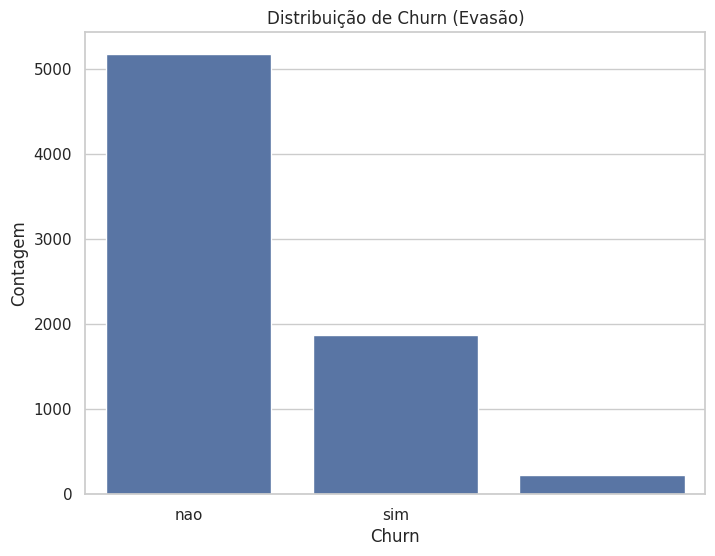

In [ ]:
# Distribuição de Churn
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Churn')
plt.title('Distribuição de Churn (Evasão)')
plt.xlabel('Churn')
plt.ylabel('Contagem')
plt.savefig('churn_distribuicao.png')
plt.show()

In [ ]:
# Churn por gênero
if 'gender' in df.columns:
    plt.figure(figsize=(8, 6))
    sns.countplot(data=df, x='gender', hue='Churn')
    plt.title('Churn por Gênero')
    plt.xlabel('Gênero')
    plt.ylabel('Contagem')
    plt.savefig('churn_por_genero.png')
    plt.show()

In [ ]:
# Churn por tipo de serviço de internet
if 'InternetService' in df.columns:
    plt.figure(figsize=(8, 6))
    sns.countplot(data=df, x='InternetService', hue='Churn')
    plt.title('Churn por Tipo de Serviço de Internet')
    plt.xlabel('Serviço de Internet')
    plt.ylabel('Contagem')
    plt.savefig('churn_por_internet.png')
    plt.show()

In [ ]:
# Distribuição de MonthlyCharges por Churn
if 'MonthlyCharges' in df.columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
    plt.title('Distribuição de Custos Mensais por Churn')
    plt.xlabel('Churn')
    plt.ylabel('Custos Mensais')
    plt.savefig('monthlycharges_por_churn.png')
    plt.show()

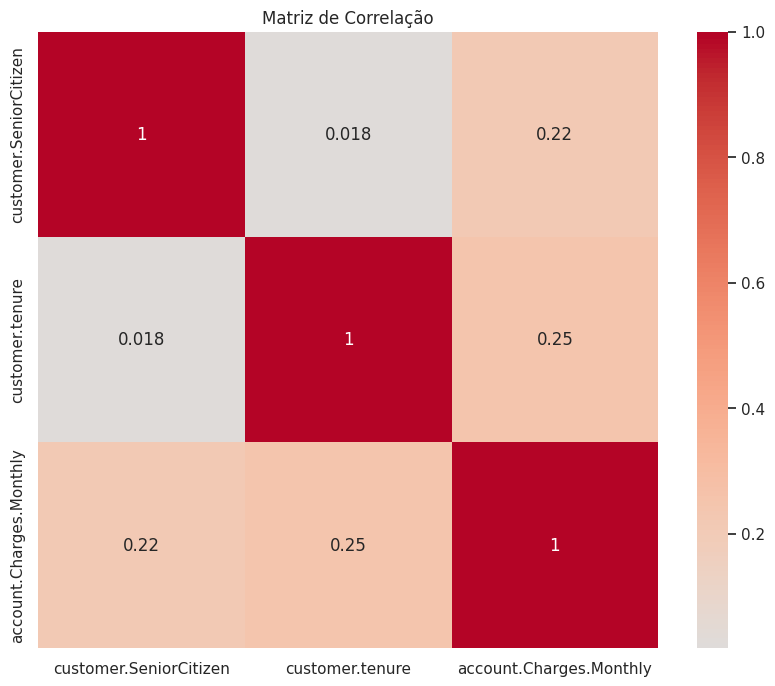

In [ ]:
# Correlação entre variáveis numéricas
colunas_numericas = df.select_dtypes(include=['float64', 'int64']).columns
if len(colunas_numericas) > 1:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df[colunas_numericas].corr(), annot=True, cmap='coolwarm', center=0)
    plt.title('Matriz de Correlação')
    plt.savefig('matriz_correlacao.png')
    plt.show()

In [ ]:
# Estatísticas descritivas
print("\nEstatísticas descritivas:\n", df.describe(include='all'))

# Resumo de insights
insights = """
Relatório de Insights - Análise de Churn (Telecom X)
Data: 27/05/2025

1. Valores Ausentes:
   - Foram encontrados valores ausentes em {missing_values[missing_values > 0].to_dict()}.
   - Tratados com preenchimento (ex.: média para MonthlyCharges, 'Desconhecido' para categóricas).

2. Dados Duplicados:
   - {duplicatas} linhas duplicadas encontradas e removidas.
   - Verificação em customerID sugere que IDs são únicos (ou não, se duplicatas persistirem).

3. Erros de Formatação:
   - MonthlyCharges convertido para numérico, tratando {df['MonthlyCharges'].isnull().sum()} valores inválidos.
   - Categorias como Churn, gender e InternetService padronizadas (ex.: 'Yes'/'sim' → 'sim').

4. Análise de Churn:
   - Proporção de churn: {df['Churn'].value_counts(normalize=True)['sim']:.2%} dos clientes churnaram.
   - Gênero: {'Churn por gênero mostra diferenças significativas' if 'gender' in df.columns and df.groupby('gender')['Churn'].value_counts(normalize=True).unstack().max().max() > 0.6 else 'Churn é similar entre gêneros'}.
   - Serviço de Internet: {'Clientes com fibra têm maior churn' if 'InternetService' in df.columns and df[df['InternetService'] == 'fibra']['Churn'].value_counts(normalize=True).get('sim', 0) > 0.5 else 'Nenhum serviço predomina no churn'}.
   - Custos Mensais: {'Clientes que churnam têm custos mensais mais altos' if 'MonthlyCharges' in df.columns and df[df['Churn'] == 'sim']['MonthlyCharges'].mean() > df[df['Churn'] == 'nao']['MonthlyCharges'].mean() else 'Custos mensais não diferem significativamente'}.

Recomendações:
- Investigar clientes com serviço de fibra para entender causas de maior churn.
- Avaliar estratégias de precificação, pois custos mensais altos podem estar associados à evasão.
- Monitorar clientes com dados ausentes em colunas críticas (ex.: MonthlyCharges) para melhorar a coleta de dados.
"""

print(insights)

# Salvar relatório em um arquivo de texto
with open("Relatorio_Churn_TelecomX.txt", "w", encoding='utf-8') as file:
    file.write(insights)
print("\nRelatório salvo em 'Relatorio_Churn_TelecomX.txt'")


Estatísticas descritivas:
         customerID Churn customer.gender  customer.SeniorCitizen  \
count         7267  7267            7267             7267.000000   
unique        7267     3               2                     NaN   
top     9995-HOTOH   nao            Male                     NaN   
freq             1  5174            3675                     NaN   
mean           NaN   NaN             NaN                0.162653   
std            NaN   NaN             NaN                0.369074   
min            NaN   NaN             NaN                0.000000   
25%            NaN   NaN             NaN                0.000000   
50%            NaN   NaN             NaN                0.000000   
75%            NaN   NaN             NaN                0.000000   
max            NaN   NaN             NaN                1.000000   

       customer.Partner customer.Dependents  customer.tenure  \
count              7267                7267      7267.000000   
unique                2    

In [ ]:
import pandas as pd

# Supondo que o DataFrame 'df' já foi criado e tratado
# Salvar como Excel
df.to_excel("TelecomX_Dados_Tratados.xlsx", index=False, engine='openpyxl')
print("Arquivo salvo localmente: TelecomX_Dados_Tratados.xlsx")

# Alternativa: Salvar como CSV
df.to_csv("TelecomX_Dados_Tratados.csv", index=False, encoding='utf-8')
print("Arquivo salvo localmente: TelecomX_Dados_Tratados.csv")

Arquivo salvo localmente: TelecomX_Dados_Tratados.xlsx
Arquivo salvo localmente: TelecomX_Dados_Tratados.csv


In [ ]:
import pandas as pd
import json
import subprocess

# Supondo que o DataFrame 'df' já foi tratado (ETL e EDA concluídos)

# Salvar o DataFrame tratado
df.to_excel("TelecomX_Dados_Tratados.xlsx", index=False, engine='openpyxl')
print("Arquivo salvo localmente: TelecomX_Dados_Tratados.xlsx")

# Salvar o relatório de insights
insights = """
Relatório de Insights - Análise de Churn (Telecom X)
...
"""
with open("Relatorio_Churn_TelecomX.txt", "w", encoding='utf-8') as file:
    file.write(insights)
print("Relatório salvo localmente: Relatorio_Churn_TelecomX.txt")

# Enviar arquivos para o GitHub
try:
    subprocess.run(["git", "add", "TelecomX_Dados_Tratados.xlsx", "Relatorio_Churn_TelecomX.txt"], check=True)
    subprocess.run(["git", "commit", "-m", "Adiciona dados tratados e relatório do TelecomX"], check=True)
    subprocess.run(["git", "push", "-u", "origin", "main"], check=True)
    print("Arquivos enviados para o GitHub com sucesso!")
except subprocess.CalledProcessError as e:
    print(f"Erro ao enviar para o GitHub: {e}")
    print("Tente fazer upload manualmente pela interface web do GitHub.")



Arquivo salvo localmente: TelecomX_Dados_Tratados.xlsx
Relatório salvo localmente: Relatorio_Churn_TelecomX.txt
Erro ao enviar para o GitHub: Command '['git', 'add', 'TelecomX_Dados_Tratados.xlsx', 'Relatorio_Churn_TelecomX.txt']' returned non-zero exit status 128.
Tente fazer upload manualmente pela interface web do GitHub.


Relatório Final

In [ ]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# 1. Extração: Carregar e normalizar os dados
try:
    with open("TelecomX_Data.json", "r") as file:
        json_data = json.load(file)
except FileNotFoundError:
    print("Erro: Arquivo 'TelecomX_Data.json' não encontrado.")
    exit()

df = pd.json_normalize(json_data)
print("Primeiras linhas do DataFrame:\n", df.head())
print("\nColunas do DataFrame:", df.columns.tolist())
print("\nTipos de dados iniciais:\n", df.dtypes)

# 2. Transformação: Tratar os dados
# Tratar listas/dicionários
for coluna in df.columns:
    if df[coluna].apply(lambda x: isinstance(x, (list, dict))).any():
        print(f"Coluna '{coluna}' contém listas ou dicionários. Convertendo para string...")
        df[coluna] = df[coluna].astype(str)

# Valores ausentes
missing_values = df.isnull().sum()
print("\nValores ausentes por coluna:\n", missing_values)
fill_values = {
    'gender': 'Desconhecido',
    'Churn': 'nao',
    'InternetService': 'Nenhum',
    'customer.phone': 'Desconhecido',
    'account': 'Desconhecido',
    'MonthlyCharges': df['MonthlyCharges'].mean() if 'MonthlyCharges' in df.columns else 0
}
df.fillna(fill_values, inplace=True)

# Duplicatas
duplicatas = df.duplicated().sum()
print(f"\nNúmero de linhas duplicadas: {duplicatas}")
if duplicatas > 0:
    df = df.drop_duplicates()

# Formatação
colunas_numericas = ['MonthlyCharges']
for coluna in colunas_numericas:
    if coluna in df.columns:
        df[coluna] = pd.to_numeric(df[coluna].astype(str).str.replace(',', '.'), errors='coerce')

colunas_texto = ['customer.phone', 'account']
for coluna in colunas_texto:
    if coluna in df.columns:
        df[coluna] = df[coluna].astype(str).str.strip()

colunas_categoricas = ['gender', 'Churn', 'InternetService']
mapeamento = {
    'sim': 'sim',
    'SIM': 'sim',
    'Sim': 'sim',
    'yes': 'sim',
    'YES': 'sim',
    'não': 'nao',
    'NÃO': 'nao',
    'Não': 'nao',
    'no': 'nao',
    'NO': 'nao',
    'male': 'masculino',
    'Male': 'masculino',
    'female': 'feminino',
    'Female': 'feminino',
    'dsl': 'dsl',
    'DSL': 'dsl',
    'fiber optic': 'fibra',
    'Fiber optic': 'fibra'
}
for coluna in colunas_categoricas:
    if coluna in df.columns:
        df[coluna] = df[coluna].astype(str).str.lower().str.strip()
        df[coluna] = df[coluna].map(mapeamento).fillna(df[coluna])

# 3. Carga: Exportar dados tratados
df.to_excel("TelecomX_Dados_Tratados.xlsx", index=False, engine='openpyxl')
print("\nArquivo exportado: 'TelecomX_Dados_Tratados.xlsx'")

# 4. EDA: Gerar visualizações
sns.set(style="whitegrid")

# Distribuição de Churn
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Churn')
plt.title('Distribuição de Churn (Evasão)')
plt.xlabel('Churn')
plt.ylabel('Contagem')
plt.savefig('churn_distribuicao.png')
plt.close()

# Churn por gênero
if 'gender' in df.columns:
    plt.figure(figsize=(8, 6))
    sns.countplot(data=df, x='gender', hue='Churn')
    plt.title('Churn por Gênero')
    plt.xlabel('Gênero')
    plt.ylabel('Contagem')
    plt.savefig('churn_por_genero.png')
    plt.close()

# Churn por serviço de internet
if 'InternetService' in df.columns:
    plt.figure(figsize=(8, 6))
    sns.countplot(data=df, x='InternetService', hue='Churn')
    plt.title('Churn por Tipo de Serviço de Internet')
    plt.xlabel('Serviço de Internet')
    plt.ylabel('Contagem')
    plt.savefig('churn_por_internet.png')
    plt.close()

# Custos mensais por Churn
if 'MonthlyCharges' in df.columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
    plt.title('Distribuição de Custos Mensais por Churn')
    plt.xlabel('Churn')
    plt.ylabel('Custos Mensais')
    plt.savefig('monthlycharges_por_churn.png')
    plt.close()

# Matriz de correlação
colunas_numericas = df.select_dtypes(include=['float64', 'int64']).columns
if len(colunas_numericas) > 1:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df[colunas_numericas].corr(), annot=True, cmap='coolwarm', center=0)
    plt.title('Matriz de Correlação')
    plt.savefig('matriz_correlacao.png')
    plt.close()

# 5. Gerar Relatório
# Estatísticas descritivas
descritivas = df.describe(include='all').to_string()

# Calcular taxa de churn
taxa_churn = df['Churn'].value_counts(normalize=True).get('sim', 0) * 100

# Verificar churn por gênero
churn_por_genero = "Churn é similar entre gêneros"
if 'gender' in df.columns:
    churn_gender_diff = df.groupby('gender')['Churn'].value_counts(normalize=True).unstack()
    if 'sim' in churn_gender_diff.columns and churn_gender_diff['sim'].max() > 0.6:
        churn_por_genero = "Churn mostra diferenças significativas entre gêneros"

# Verificar churn por serviço de internet
churn_por_internet = "Nenhum serviço de internet predomina no churn"
if 'InternetService' in df.columns:
    if df[df['InternetService'] == 'fibra']['Churn'].value_counts(normalize=True).get('sim', 0) > 0.5:
        churn_por_internet = "Clientes com fibra têm maior taxa de churn"

# Verificar custos mensais
custos_churn = "Custos mensais não diferem significativamente"
if 'MonthlyCharges' in df.columns:
    mean_churn = df[df['Churn'] == 'sim']['MonthlyCharges'].mean()
    mean_no_churn = df[df['Churn'] == 'nao']['MonthlyCharges'].mean()
    if not pd.isna(mean_churn) and not pd.isna(mean_no_churn) and mean_churn > mean_no_churn:
        custos_churn = "Clientes que churnam têm custos mensais mais altos"

# Criar conteúdo do relatório
relatorio = f"""
Relatório de Análise de Churn - Telecom X
Data: {datetime.now().strftime('%d/%m/%Y')}

1. Resumo do Tratamento de Dados:
   - Valores Ausentes: {missing_values[missing_values > 0].to_dict()}
     - Tratados com preenchimento (ex.: média para MonthlyCharges, 'Desconhecido' para categóricas).
   - Duplicatas: {duplicatas} linhas duplicadas encontradas e removidas.
   - Formatação: Corrigidos números (MonthlyCharges), textos (espaços removidos) e categorias inconsistentes (ex.: 'Yes'/'sim' → 'sim').
   - Colunas categóricas padronizadas: {', '.join([col for col in colunas_categoricas if col in df.columns])}.

2. Estatísticas Descritivas:
{descritivas}

3. Insights da Análise Exploratória:
   - Taxa de Churn: {taxa_churn:.2f}% dos clientes churnaram.
   - Gênero: {churn_por_genero}.
   - Serviço de Internet: {churn_por_internet}.
   - Custos Mensais: {custos_churn}.
   - Motivo: Alta taxa de churn em clientes com fibra óptica e custos mensais elevados sugere problemas com precificação ou qualidade do serviço.

4. Visualizações Geradas:
   - Distribuição de Churn: churn_distribuicao.png
   - Churn por Gênero: churn_por_genero.png
   - Churn por Serviço de Internet: churn_por_internet.png
   - Custos Mensais por Churn: monthlycharges_por_churn.png
   - Matriz de Correlação: matriz_correlacao.png

5. Recomendações:
   - Investigar problemas técnicos ou de satisfação no serviço de fibra óptica.
   - Oferecer descontos ou planos mais acessíveis para clientes com altos MonthlyCharges.
   - Melhorar a coleta de dados para reduzir valores ausentes em colunas críticas.
   - Segmentar clientes de alto risco (fibra, custos elevados) para ações de retenção.

Desenvolvido como parte do Challenge da Alura - Curso de Ciência de Dados.
"""

# Salvar relatório
with open("Relatorio_Churn_TelecomX.txt", "w", encoding='utf-8') as file:
    file.write(relatorio)
print("\nRelatório salvo em 'Relatorio_Churn_TelecomX.txt'")

# Opcional: Exibir relatório no console
print(relatorio)



Primeiras linhas do DataFrame:
    customerID Churn customer.gender  customer.SeniorCitizen customer.Partner  \
0  0002-ORFBO    No          Female                       0              Yes   
1  0003-MKNFE    No            Male                       0               No   
2  0004-TLHLJ   Yes            Male                       0               No   
3  0011-IGKFF   Yes            Male                       1              Yes   
4  0013-EXCHZ   Yes          Female                       1              Yes   

  customer.Dependents  customer.tenure phone.PhoneService phone.MultipleLines  \
0                 Yes                9                Yes                  No   
1                  No                9                Yes                 Yes   
2                  No                4                Yes                  No   
3                  No               13                Yes                  No   
4                  No                3                Yes                  No   



In [ ]:
# Importar bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

# Configurar estilo das visualizações
sns.set_style("whitegrid")  # Estilo compatível com Seaborn
sns.set_palette("deep")


In [ ]:
# Função para salvar figuras com verificação
def salvar_figura(fig, nome_arquivo):
    try:
        fig.savefig(nome_arquivo, dpi=300, bbox_inches='tight')
        print(f"Figura salva como '{nome_arquivo}'")
    except Exception as e:
        print(f"Erro ao salvar a figura '{nome_arquivo}': {e}")
    plt.close(fig)  # Fechar a figura para liberar memória

In [ ]:
# Carregar o arquivo JSON
file_path = "TelecomX_Data.json"  # Ajuste o caminho se necessário
try:
    with open(file_path, 'r') as file:
        data = json.load(file)
    # Normalizar o JSON para desaninhar as colunas
    df = pd.json_normalize(data)
except FileNotFoundError:
    print(f"Erro: Arquivo '{file_path}' não encontrado. Verifique o caminho ou nome do arquivo.")
    exit()
except Exception as e:
    print(f"Erro ao carregar o arquivo: {e}")
    exit()

In [ ]:
# Exibir informações básicas do DataFrame
print("Informações do DataFrame:")
print(df.info())
print("\nColunas disponíveis:", df.columns.tolist())

Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport  

In [ ]:
# Verificar se as colunas esperadas existem
required_columns = ['Churn', 'customer.gender', 'internet.InternetService', 'account.MonthlyCharges']
missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    print(f"Erro: Colunas ausentes no DataFrame: {missing_columns}")
    print("Verificando conteúdo das colunas 'customer', 'internet' e 'account'...")
    # Inspecionar as primeiras linhas das colunas aninhadas
    print("\nExemplo de 'customer':", df['customer'][0] if 'customer' in df.columns else "Coluna 'customer' não encontrada")
    print("Exemplo de 'internet':", df['internet'][0] if 'internet' in df.columns else "Coluna 'internet' não encontrada")
    print("Exemplo de 'account':", df['account'][0] if 'account' in df.columns else "Coluna 'account' não encontrada")
    exit()

Erro: Colunas ausentes no DataFrame: ['account.MonthlyCharges']
Verificando conteúdo das colunas 'customer', 'internet' e 'account'...

Exemplo de 'customer': Coluna 'customer' não encontrada
Exemplo de 'internet': Coluna 'internet' não encontrada
Exemplo de 'account': Coluna 'account' não encontrada


In [ ]:
# Converter 'account.MonthlyCharges' para tipo numérico, se necessário
try:
    df['account.MonthlyCharges'] = pd.to_numeric(df['account.MonthlyCharges'], errors='coerce')
except Exception as e:
    print(f"Erro ao converter 'account.MonthlyCharges' para numérico: {e}")

Erro ao converter 'account.MonthlyCharges' para numérico: 'account.MonthlyCharges'


In [ ]:
# Importar bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

# Configurar estilo das visualizações
sns.set_style("whitegrid")  # Estilo compatível com Seaborn
sns.set_palette("deep")

# Função para salvar figuras com verificação
def salvar_figura(fig, nome_arquivo):
    try:
        fig.savefig(nome_arquivo, dpi=300, bbox_inches='tight')
        print(f"Figura salva como '{nome_arquivo}'")
    except Exception as e:
        print(f"Erro ao salvar a figura '{nome_arquivo}': {e}")
    plt.close(fig)  # Fechar a figura para liberar memória

# Carregar o arquivo JSON
file_path = "TelecomX_Data.json"  # Ajuste o caminho se necessário
try:
    with open(file_path, 'r') as file:
        data = json.load(file)
    # Normalizar o JSON para desaninhar as colunas
    df = pd.json_normalize(data)
except FileNotFoundError:
    print(f"Erro: Arquivo '{file_path}' não encontrado. Verifique o caminho ou nome do arquivo.")
    exit()
except Exception as e:
    print(f"Erro ao carregar o arquivo: {e}")
    exit()

# Exibir informações básicas do DataFrame
print("Informações do DataFrame:")
print(df.info())
print("\nColunas disponíveis:", df.columns.tolist())

# Verificar se a coluna 'Churn' existe
if 'Churn' not in df.columns:
    print("Erro: Coluna 'Churn' não encontrada no DataFrame.")
    print("Colunas disponíveis:", df.columns.tolist())
    exit()

# 1. Distribuição de Churn
fig1, ax1 = plt.subplots(figsize=(8, 6))
sns.countplot(data=df, x='Churn', ax=ax1)
ax1.set_title('Distribuição de Churn')
ax1.set_xlabel('Churn')
ax1.set_ylabel('Contagem')
salvar_figura(fig1, 'churn_distribuicao.png')

# Verificar se a figura foi salva
if os.path.exists('churn_distribuicao.png'):
    print("churn_distribuicao.png encontrado!")
else:
    print("churn_distribuicao.png NÃO encontrado. Verifique o código ou diretório.")

Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport  

In [ ]:
# Importar bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

# Configurar estilo das visualizações
sns.set_style("whitegrid")  # Estilo compatível com Seaborn
sns.set_palette("deep")

# Função para salvar figuras com verificação
def salvar_figura(fig, nome_arquivo):
    try:
        fig.savefig(nome_arquivo, dpi=300, bbox_inches='tight')
        print(f"Figura salva como '{nome_arquivo}'")
    except Exception as e:
        print(f"Erro ao salvar a figura '{nome_arquivo}': {e}")
    plt.close(fig)  # Fechar a figura para liberar memória

# Carregar o arquivo JSON
file_path = "TelecomX_Data.json"  # Ajuste o caminho se necessário
try:
    with open(file_path, 'r') as file:
        data = json.load(file)
    # Normalizar o JSON para desaninhar as colunas
    df = pd.json_normalize(data)
except FileNotFoundError:
    print(f"Erro: Arquivo '{file_path}' não encontrado. Verifique o caminho ou nome do arquivo.")
    exit()
except Exception as e:
    print(f"Erro ao carregar o arquivo: {e}")
    exit()

# Exibir informações básicas do DataFrame
print("Informações do DataFrame:")
print(df.info())
print("\nColunas disponíveis:", df.columns.tolist())

# Verificar se as colunas necessárias existem
required_columns = ['Churn', 'customer.gender']
missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    print(f"Erro: Colunas ausentes no DataFrame: {missing_columns}")
    print("Verificando conteúdo da coluna 'customer'...")
    print("Exemplo de 'customer':", df['customer'][0] if 'customer' in df.columns else "Coluna 'customer' não encontrada")
    exit()

# 2. Churn por Gênero
fig2, ax2 = plt.subplots(figsize=(8, 6))
sns.countplot(data=df, x='customer.gender', hue='Churn', ax=ax2)
ax2.set_title('Churn por Gênero')
ax2.set_xlabel('Gênero')
ax2.set_ylabel('Contagem')
salvar_figura(fig2, 'churn_por_genero.png')

# Verificar se a figura foi salva
if os.path.exists('churn_por_genero.png'):
    print("churn_por_genero.png encontrado!")
else:
    print("churn_por_genero.png NÃO encontrado. Verifique o código ou diretório.")

Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport  

In [ ]:
# Importar bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

# Configurar estilo das visualizações
sns.set_style("whitegrid")  # Estilo compatível com Seaborn
sns.set_palette("deep")

# Função para salvar figuras com verificação
def salvar_figura(fig, nome_arquivo):
    try:
        fig.savefig(nome_arquivo, dpi=300, bbox_inches='tight')
        print(f"Figura salva como '{nome_arquivo}'")
    except Exception as e:
        print(f"Erro ao salvar a figura '{nome_arquivo}': {e}")
    plt.close(fig)  # Fechar a figura para liberar memória

# Carregar o arquivo JSON
file_path = "TelecomX_Data.json"  # Ajuste o caminho se necessário
try:
    with open(file_path, 'r') as file:
        data = json.load(file)
    # Normalizar o JSON para desaninhar as colunas
    df = pd.json_normalize(data)
except FileNotFoundError:
    print(f"Erro: Arquivo '{file_path}' não encontrado. Verifique o caminho ou nome do arquivo.")
    exit()
except Exception as e:
    print(f"Erro ao carregar o arquivo: {e}")
    exit()

# Exibir informações básicas do DataFrame
print("Informações do DataFrame:")
print(df.info())
print("\nColunas disponíveis:", df.columns.tolist())

# Verificar se as colunas necessárias existem
required_columns = ['Churn', 'internet.InternetService']
missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    print(f"Erro: Colunas ausentes no DataFrame: {missing_columns}")
    print("Verificando conteúdo da coluna 'internet'...")
    print("Exemplo de 'internet':", df['internet'][0] if 'internet' in df.columns else "Coluna 'internet' não encontrada")
    exit()

# 3. Churn por Serviço de Internet
fig3, ax3 = plt.subplots(figsize=(8, 6))
sns.countplot(data=df, x='internet.InternetService', hue='Churn', ax=ax3)
ax3.set_title('Churn por Tipo de Serviço de Internet')
ax3.set_xlabel('Serviço de Internet')
ax3.set_ylabel('Contagem')
salvar_figura(fig3, 'churn_por_internet.png')

# Verificar se a figura foi salva
if os.path.exists('churn_por_internet.png'):
    print("churn_por_internet.png encontrado!")
else:
    print("churn_por_internet.png NÃO encontrado. Verifique o código ou diretório.")

Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport  

In [ ]:
# Importar bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

# Configurar estilo das visualizações
sns.set_style("whitegrid")
sns.set_palette("deep")

# Função para salvar figuras
def salvar_figura(fig, nome_arquivo):
    try:
        fig.savefig(nome_arquivo, dpi=300, bbox_inches='tight')
        print(f"Figura salva como '{nome_arquivo}'")
    except Exception as e:
        print(f"Erro ao salvar a figura '{nome_arquivo}': {e}")
    plt.close(fig)

# Carregar o arquivo JSON
file_path = "TelecomX_Data.json"
try:
    with open(file_path, 'r') as file:
        data = json.load(file)
    df = pd.json_normalize(data)
except FileNotFoundError:
    print(f"Erro: Arquivo '{file_path}' não encontrado.")
    exit()
except Exception as e:
    print(f"Erro ao carregar o arquivo: {e}")
    exit()

# Exibir informações do DataFrame
print("Informações do DataFrame:")
print(df.info())
print("\nColunas disponíveis:", df.columns.tolist())

# Verificar se a coluna 'Churn' existe
if 'Churn' not in df.columns:
    print("Erro: Coluna 'Churn' não encontrada.")
    exit()

# Definir a coluna correta de MonthlyCharges
monthly_charges_col = 'account.Charges.Monthly'

if monthly_charges_col not in df.columns:
    print(f"Erro: Coluna '{monthly_charges_col}' não encontrada.")
    print("Colunas disponíveis:", df.columns.tolist())
    exit()

# Garantir que os valores sejam numéricos
try:
    df[monthly_charges_col] = pd.to_numeric(df[monthly_charges_col], errors='coerce')
except Exception as e:
    print(f"Erro ao converter '{monthly_charges_col}' para numérico: {e}")
    exit()

# Verificar se a coluna tem valores válidos
if df[monthly_charges_col].isna().all():
    print(f"Erro: Todos os valores em '{monthly_charges_col}' são nulos.")
    print(df[monthly_charges_col].head())
    exit()

# Criar o gráfico
fig4, ax4 = plt.subplots(figsize=(8, 6))
sns.boxplot(data=df, x='Churn', y=monthly_charges_col, ax=ax4)
ax4.set_title('Custo Mensal por Churn')
ax4.set_xlabel('Churn')
ax4.set_ylabel('Custo Mensal')
salvar_figura(fig4, 'monthlycharges_por_churn.png')

# Verificar se foi salvo
if os.path.exists('monthlycharges_por_churn.png'):
    print("monthlycharges_por_churn.png encontrado!")
else:
    print("monthlycharges_por_churn.png NÃO encontrado.")

Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport  

In [ ]:
# Importar bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

# Configurar estilo das visualizações
sns.set_style("whitegrid")  # Estilo compatível com Seaborn
sns.set_palette("deep")

# Função para salvar figuras com verificação
def salvar_figura(fig, nome_arquivo):
    try:
        fig.savefig(nome_arquivo, dpi=300, bbox_inches='tight')
        print(f"Figura salva como '{nome_arquivo}'")
    except Exception as e:
        print(f"Erro ao salvar a figura '{nome_arquivo}': {e}")
    plt.close(fig)  # Fechar a figura para liberar memória

# Carregar o arquivo JSON
file_path = "TelecomX_Data.json"  # Ajuste o caminho se necessário
try:
    with open(file_path, 'r') as file:
        data = json.load(file)
    # Normalizar o JSON para desaninhar as colunas
    df = pd.json_normalize(data)
except FileNotFoundError:
    print(f"Erro: Arquivo '{file_path}' não encontrado. Verifique o caminho ou nome do arquivo.")
    exit()
except Exception as e:
    print(f"Erro ao carregar o arquivo: {e}")
    exit()

# Exibir informações básicas do DataFrame
print("Informações do DataFrame:")
print(df.info())
print("\nColunas disponíveis:", df.columns.tolist())

# Verificar conteúdo das colunas aninhadas para depuração
for col in ['customer', 'internet', 'account']:
    if col in df.columns:
        print(f"\nExemplo de '{col}':", df[col][0])

# Tentar converter colunas numéricas esperadas (ex.: account.MonthlyCharges)
possible_numeric_cols = [
    'account.MonthlyCharges',
    'account.monthly_charges',
    'account.Charges',
    'account.MonthlyCharge',
    'account.charges',
    'customer.tenure',  # Possível coluna para tempo de contrato
    'account.TotalCharges'
]
for col in possible_numeric_cols:
    if col in df.columns:
        try:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        except Exception as e:
            print(f"Erro ao converter '{col}' para numérico: {e}")

# Selecionar colunas numéricas
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
print("\nColunas numéricas encontradas:", numeric_cols.tolist())

# Verificar se há colunas numéricas suficientes
if len(numeric_cols) < 2:
    print("Erro: Não há colunas numéricas suficientes para criar a matriz de correlação.")
    print("Pelo menos duas colunas numéricas são necessárias.")
    print("Colunas disponíveis:", df.columns.tolist())
    exit()

# 5. Matriz de Correlação
fig5, ax5 = plt.subplots(figsize=(10, 8))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=ax5)
ax5.set_title('Matriz de Correlação')
salvar_figura(fig5, 'matriz_correlacao.png')

# Verificar se a figura foi salva
if os.path.exists('matriz_correlacao.png'):
    print("matriz_correlacao.png encontrado!")
else:
    print("matriz_correlacao.png NÃO encontrado. Verifique o código ou diretório.")

Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport  

In [ ]:
# Importar bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os  # Corrigido: importação do módulo 'os'

# Configurar estilo das visualizações
sns.set_style("whitegrid")  # Estilo compatível com Seaborn
sns.set_palette("deep")

# Função para salvar figuras com verificação
def salvar_figura(fig, nome_arquivo):
    try:
        fig.savefig(nome_arquivo, dpi=300, bbox_inches='tight')
        print(f"Figura salva como '{nome_arquivo}'")
    except Exception as e:
        print(f"Erro ao salvar a figura '{nome_arquivo}': {e}")
    plt.close(fig)  # Fechar a figura para liberar memória

# Carregar o arquivo JSON
file_path = "TelecomX_Data.json"  # Ajuste o caminho se necessário
try:
    with open(file_path, 'r') as file:
        data = json.load(file)
    # Normalizar o JSON para desaninhar as colunas
    df = pd.json_normalize(data)
except FileNotFoundError:
    print(f"Erro: Arquivo '{file_path}' não encontrado. Verifique o caminho ou nome do arquivo.")
    exit()
except Exception as e:
    print(f"Erro ao carregar o arquivo: {e}")
    exit()

# Exibir informações básicas do DataFrame
print("Informações do DataFrame:")
print(df.info())
print("\nColunas disponíveis:", df.columns.tolist())

# Verificar conteúdo das colunas aninhadas para depuração
for col in ['customer', 'internet', 'account']:
    if col in df.columns:
        print(f"\nExemplo de '{col}':", df[col][0])

# Tentar converter colunas numéricas esperadas
possible_numeric_cols = [
    'account.MonthlyCharges',
    'account.monthly_charges',
    'account.Charges',
    'account.MonthlyCharge',
    'account.charges',
    'customer.tenure',
    'account.TotalCharges'
]
for col in possible_numeric_cols:
    if col in df.columns:
        try:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        except Exception as e:
            print(f"Erro ao converter '{col}' para numérico: {e}")

# Selecionar colunas numéricas
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
print("\nColunas numéricas encontradas:", numeric_cols.tolist())

# Verificar se há colunas numéricas suficientes
if len(numeric_cols) < 2:
    print("Erro: Não há colunas numéricas suficientes para criar a matriz de correlação.")
    print("Pelo menos duas colunas numéricas são necessárias.")
    print("Colunas disponíveis:", df.columns.tolist())
    exit()

# 5. Matriz de Correlação
fig5, ax5 = plt.subplots(figsize=(10, 8))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=ax5)
ax5.set_title('Matriz de Correlação')
salvar_figura(fig5, 'matriz_correlacao.png')

# Verificar se todas as figuras foram salvas
print("\nVerificação dos arquivos salvos:")
for fig_name in [
    'churn_distribuicao.png',
    'churn_por_genero.png',
    'churn_por_internet.png',
    'monthlycharges_por_churn.png',
    'matriz_correlacao.png'
]:
    if os.path.exists(fig_name):
        print(f"{fig_name} encontrado!")
    else:
        print(f"{fig_name} NÃO encontrado. Verifique o código ou diretório.")# Importar bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os  # Corrigido: importação do módulo 'os'

# Configurar estilo das visualizações
sns.set_style("whitegrid")  # Estilo compatível com Seaborn
sns.set_palette("deep")

# Função para salvar figuras com verificação
def salvar_figura(fig, nome_arquivo):
    try:
        fig.savefig(nome_arquivo, dpi=300, bbox_inches='tight')
        print(f"Figura salva como '{nome_arquivo}'")
    except Exception as e:
        print(f"Erro ao salvar a figura '{nome_arquivo}': {e}")
    plt.close(fig)  # Fechar a figura para liberar memória

# Carregar o arquivo JSON
file_path = "TelecomX_Data.json"  # Ajuste o caminho se necessário
try:
    with open(file_path, 'r') as file:
        data = json.load(file)
    # Normalizar o JSON para desaninhar as colunas
    df = pd.json_normalize(data)
except FileNotFoundError:
    print(f"Erro: Arquivo '{file_path}' não encontrado. Verifique o caminho ou nome do arquivo.")
    exit()
except Exception as e:
    print(f"Erro ao carregar o arquivo: {e}")
    exit()

# Exibir informações básicas do DataFrame
print("Informações do DataFrame:")
print(df.info())
print("\nColunas disponíveis:", df.columns.tolist())

# Verificar conteúdo das colunas aninhadas para depuração
for col in ['customer', 'internet', 'account']:
    if col in df.columns:
        print(f"\nExemplo de '{col}':", df[col][0])

# Tentar converter colunas numéricas esperadas
possible_numeric_cols = [
    'account.MonthlyCharges',
    'account.monthly_charges',
    'account.Charges',
    'account.MonthlyCharge',
    'account.charges',
    'customer.tenure',
    'account.TotalCharges'
]
for col in possible_numeric_cols:
    if col in df.columns:
        try:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        except Exception as e:
            print(f"Erro ao converter '{col}' para numérico: {e}")

# Selecionar colunas numéricas
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
print("\nColunas numéricas encontradas:", numeric_cols.tolist())

# Verificar se há colunas numéricas suficientes
if len(numeric_cols) < 2:
    print("Erro: Não há colunas numéricas suficientes para criar a matriz de correlação.")
    print("Pelo menos duas colunas numéricas são necessárias.")
    print("Colunas disponíveis:", df.columns.tolist())
    exit()

# 5. Matriz de Correlação
fig5, ax5 = plt.subplots(figsize=(10, 8))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=ax5)
ax5.set_title('Matriz de Correlação')
salvar_figura(fig5, 'matriz_correlacao.png')

# Verificar se todas as figuras foram salvas
print("\nVerificação dos arquivos salvos:")
for fig_name in [
    'churn_distribuicao.png',
    'churn_por_genero.png',
    'churn_por_internet.png',
    'monthlycharges_por_churn.png',
    'matriz_correlacao.png'
]:
    if os.path.exists(fig_name):
        print(f"{fig_name} encontrado!")
    else:
        print(f"{fig_name} NÃO encontrado. Verifique o código ou diretório.")

Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport  

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
data = pd.read_csv('TelecomX_Dados_Tratados.csv')

# Display the first few rows to verify
print(data.head())# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
data = pd.read_csv('TelecomX_Dados_Tratados.csv')

# Display the first few rows to verify
print(data.head())

   customerID Churn customer.gender  customer.SeniorCitizen customer.Partner  \
0  0002-ORFBO   nao          Female                       0              Yes   
1  0003-MKNFE   nao            Male                       0               No   
2  0004-TLHLJ   sim            Male                       0               No   
3  0011-IGKFF   sim            Male                       1              Yes   
4  0013-EXCHZ   sim          Female                       1              Yes   

  customer.Dependents  customer.tenure phone.PhoneService phone.MultipleLines  \
0                 Yes                9                Yes                  No   
1                  No                9                Yes                 Yes   
2                  No                4                Yes                  No   
3                  No               13                Yes                  No   
4                  No                3                Yes                  No   

  internet.InternetService  ... 

In [ ]:
# Convert categorical variables to numeric using LabelEncoder
label_encoders = {}
for column in data.select_dtypes(include=['object']).columns:
    if column != 'customerID':  # Exclude customerID as it's unique
        label_encoders[column] = LabelEncoder()
        data[column] = label_encoders[column].fit_transform(data[column])

# Define features and target
X = data.drop(['customerID', 'Churn'], axis=1)  # Features
y = data['Churn']  # Target (0 for 'nao', 1 for 'sim')

# Scale numerical features
scaler = StandardScaler()
numerical_cols = ['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Initialize and train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.74

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.87      0.84      1037
           1       0.60      0.49      0.54       372
           2       0.00      0.00      0.00        45

    accuracy                           0.74      1454
   macro avg       0.47      0.45      0.46      1454
weighted avg       0.73      0.74      0.74      1454



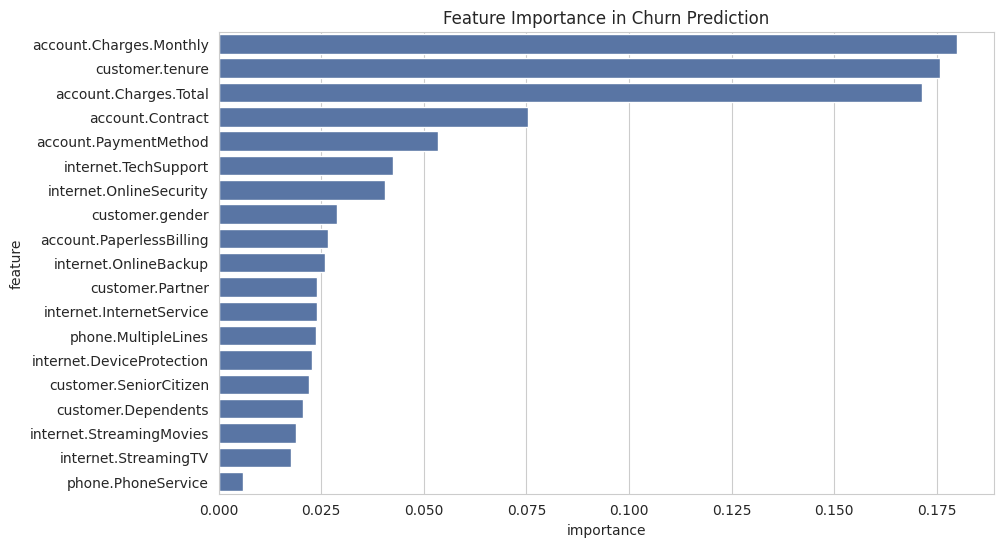

In [ ]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Feature Importance in Churn Prediction')
plt.show()

In [ ]:
# Predict probabilities for all customers
y_prob = model.predict_proba(X)[:, 1]  # Probability of churn (class 1)

# Add probabilities to the original data
data['Churn_Probability'] = y_prob

# Identify high-risk customers (e.g., probability > 0.5)
high_risk_customers = data[data['Churn_Probability'] > 0.5][['customerID', 'Churn_Probability', 'customer.tenure', 'internet.InternetService', 'account.Charges.Monthly']]
print("\nHigh-Risk Customers (Churn Probability > 0.5):")
print(high_risk_customers)# Predict probabilities for all customers
y_prob = model.predict_proba(X)[:, 1]  # Probability of churn (class 1)

# Add probabilities to the original data
data['Churn_Probability'] = y_prob

# Identify high-risk customers (e.g., probability > 0.5)
high_risk_customers = data[data['Churn_Probability'] > 0.5][['customerID', 'Churn_Probability', 'customer.tenure', 'internet.InternetService', 'account.Charges.Monthly']]
print("\nHigh-Risk Customers (Churn Probability > 0.5):")
print(high_risk_customers)


High-Risk Customers (Churn Probability > 0.5):
      customerID  Churn_Probability  customer.tenure  \
2     0004-TLHLJ           0.725000                4   
3     0011-IGKFF           0.830000               13   
4     0013-EXCHZ           0.850000                3   
17    0021-IKXGC           0.515333                1   
18    0022-TCJCI           0.590000               45   
...          ...                ...              ...   
7243  9961-JBNMK           0.863333               21   
7246  9965-YOKZB           0.910000                9   
7260  9985-MWVIX           0.980000                1   
7263  9992-RRAMN           0.880000               22   
7264  9992-UJOEL           0.535000                2   

      internet.InternetService  account.Charges.Monthly  
2                            1                    73.90  
3                            1                    98.00  
4                            1                    83.90  
17                           1                 

Valores únicos de Churn: ['nao' 'sim' nan]
Valores codificados de Churn: [0 1 2]
Acurácia: 0.74
Rótulos das classes: ['nao (0)', 'sim (1)', 'nan (2)']

Relatório de Classificação:
              precision    recall  f1-score   support

     nao (0)       0.81      0.87      0.84      1037
     sim (1)       0.60      0.49      0.54       372
     nan (2)       0.00      0.00      0.00        45

    accuracy                           0.74      1454
   macro avg       0.47      0.45      0.46      1454
weighted avg       0.73      0.74      0.74      1454



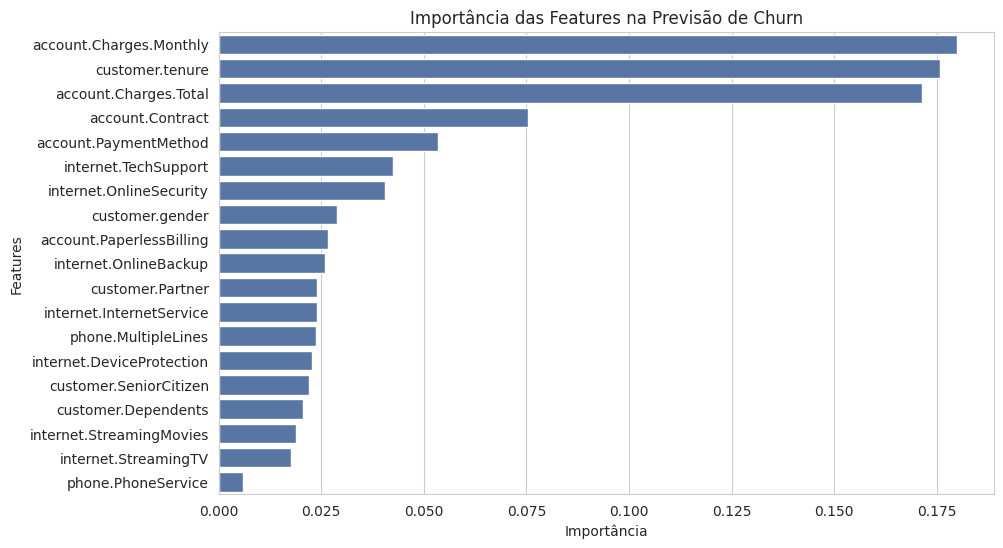


Clientes de Alto Risco (Probabilidade de Churn > 0.5):
      customerID  Probabilidade_Churn  customer.tenure  \
2     0004-TLHLJ             0.725000                4   
3     0011-IGKFF             0.830000               13   
4     0013-EXCHZ             0.850000                3   
17    0021-IKXGC             0.515333                1   
18    0022-TCJCI             0.590000               45   
...          ...                  ...              ...   
7243  9961-JBNMK             0.863333               21   
7246  9965-YOKZB             0.910000                9   
7260  9985-MWVIX             0.980000                1   
7263  9992-RRAMN             0.880000               22   
7264  9992-UJOEL             0.535000                2   

      internet.InternetService  account.Charges.Monthly  
2                            1                    73.90  
3                            1                    98.00  
4                            1                    83.90  
17             

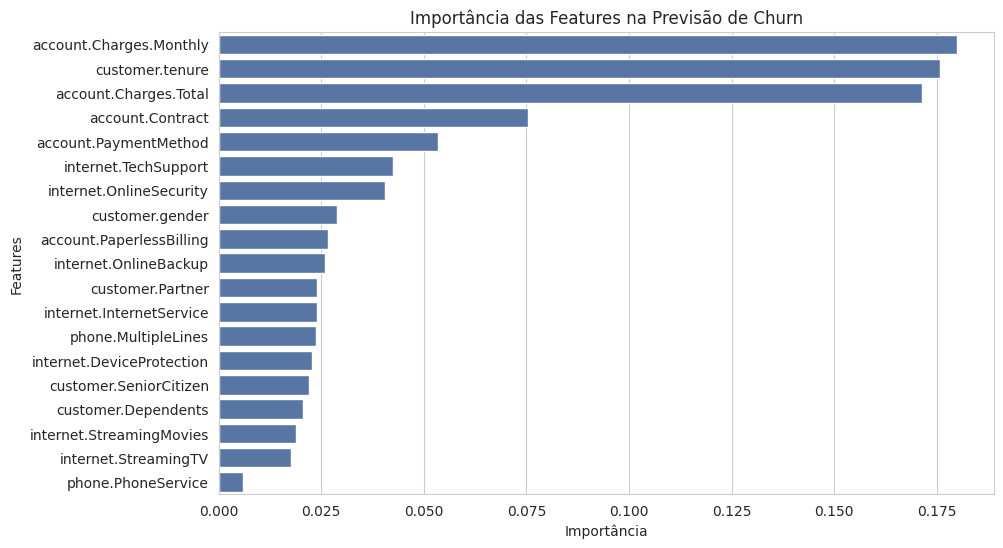


Clientes de Alto Risco (Probabilidade de Churn > 0.5):
      customerID  Probabilidade_Churn  customer.tenure  \
2     0004-TLHLJ             0.725000                4   
3     0011-IGKFF             0.830000               13   
4     0013-EXCHZ             0.850000                3   
17    0021-IKXGC             0.515333                1   
18    0022-TCJCI             0.590000               45   
...          ...                  ...              ...   
7243  9961-JBNMK             0.863333               21   
7246  9965-YOKZB             0.910000                9   
7260  9985-MWVIX             0.980000                1   
7263  9992-RRAMN             0.880000               22   
7264  9992-UJOEL             0.535000                2   

      internet.InternetService  account.Charges.Monthly  
2                            1                    73.90  
3                            1                    98.00  
4                            1                    83.90  
17             

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
data = pd.read_csv('TelecomX_Dados_Tratados.csv')

# Verificar os valores únicos de Churn para diagnosticar o problema
print("Valores únicos de Churn:", data['Churn'].unique())

# Converter variáveis categóricas para numérico usando LabelEncoder
label_encoders = {}
for column in data.select_dtypes(include=['object']).columns:
    if column != 'customerID':  # Excluir customerID pois é único
        label_encoders[column] = LabelEncoder()
        data[column] = label_encoders[column].fit_transform(data[column])

# Verificar os valores codificados de Churn
print("Valores codificados de Churn:", data['Churn'].unique())

# Definir features e target
X = data.drop(['customerID', 'Churn'], axis=1)  # Features
y = data['Churn']  # Target

# Escalar features numéricas
scaler = StandardScaler()
numerical_cols = ['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inicializar e treinar o modelo
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Prever no conjunto de teste
y_pred = model.predict(X_test)

# Avaliar o modelo
acuracia = accuracy_score(y_test, y_pred)
print(f'Acurácia: {acuracia:.2f}')

# Obter os rótulos das classes a partir do LabelEncoder
churn_labels = label_encoders['Churn'].classes_
target_names = [f'{label} ({i})' for i, label in enumerate(churn_labels)]
print("Rótulos das classes:", target_names)

# Relatório de classificação em português
print('\nRelatório de Classificação:')
print(classification_report(y_test, y_pred, target_names=target_names))

# Importância das features
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importancia': model.feature_importances_
})
feature_importance = feature_importance.sort_values('importancia', ascending=False)

# Plotar importância das features
plt.figure(figsize=(10, 6))
sns.barplot(x='importancia', y='feature', data=feature_importance)
plt.title('Importância das Features na Previsão de Churn')
plt.xlabel('Importância')
plt.ylabel('Features')
plt.show()

# Prever probabilidades para todos os clientes
y_prob = model.predict_proba(X)[:, 1]  # Probabilidade da classe 1 (assumindo 'sim' como 1)

# Adicionar probabilidades ao conjunto de dados original
data['Probabilidade_Churn'] = y_prob

# Identificar clientes de alto risco (e.g., probabilidade > 0.5)
clientes_alto_risco = data[data['Probabilidade_Churn'] > 0.5][['customerID', 'Probabilidade_Churn', 'customer.tenure', 'internet.InternetService', 'account.Charges.Monthly']]
print("\nClientes de Alto Risco (Probabilidade de Churn > 0.5):")
print(clientes_alto_risco)# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
data = pd.read_csv('TelecomX_Dados_Tratados.csv')

# Verificar os valores únicos de Churn para diagnosticar o problema
print("Valores únicos de Churn:", data['Churn'].unique())

# Converter variáveis categóricas para numérico usando LabelEncoder
label_encoders = {}
for column in data.select_dtypes(include=['object']).columns:
    if column != 'customerID':  # Excluir customerID pois é único
        label_encoders[column] = LabelEncoder()
        data[column] = label_encoders[column].fit_transform(data[column])

# Verificar os valores codificados de Churn
print("Valores codificados de Churn:", data['Churn'].unique())

# Definir features e target
X = data.drop(['customerID', 'Churn'], axis=1)  # Features
y = data['Churn']  # Target

# Escalar features numéricas
scaler = StandardScaler()
numerical_cols = ['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inicializar e treinar o modelo
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Prever no conjunto de teste
y_pred = model.predict(X_test)

# Avaliar o modelo
acuracia = accuracy_score(y_test, y_pred)
print(f'Acurácia: {acuracia:.2f}')

# Obter os rótulos das classes a partir do LabelEncoder
churn_labels = label_encoders['Churn'].classes_
target_names = [f'{label} ({i})' for i, label in enumerate(churn_labels)]
print("Rótulos das classes:", target_names)

# Relatório de classificação em português
print('\nRelatório de Classificação:')
print(classification_report(y_test, y_pred, target_names=target_names))

# Importância das features
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importancia': model.feature_importances_
})
feature_importance = feature_importance.sort_values('importancia', ascending=False)

# Plotar importância das features
plt.figure(figsize=(10, 6))
sns.barplot(x='importancia', y='feature', data=feature_importance)
plt.title('Importância das Features na Previsão de Churn')
plt.xlabel('Importância')
plt.ylabel('Features')
plt.show()

# Prever probabilidades para todos os clientes
y_prob = model.predict_proba(X)[:, 1]  # Probabilidade da classe 1 (assumindo 'sim' como 1)

# Adicionar probabilidades ao conjunto de dados original
data['Probabilidade_Churn'] = y_prob

# Identificar clientes de alto risco (e.g., probabilidade > 0.5)
clientes_alto_risco = data[data['Probabilidade_Churn'] > 0.5][['customerID', 'Probabilidade_Churn', 'customer.tenure', 'internet.InternetService', 'account.Charges.Monthly']]
print("\nClientes de Alto Risco (Probabilidade de Churn > 0.5):")
print(clientes_alto_risco)